In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.cm as cm
import seaborn as sns
import scipy.stats as ss
import pickle
import os
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist, squareform
from scipy.spatial import distance
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde
from rdkit.Chem import Draw

plt.rcParams['figure.dpi'] = 300

In [2]:
# Define some paths
root = '../../../Documents_GPU/mtb-targeted-protein-degradation/scripts'
PATH_TO_DOCKING_RESULTS_ORIGINAL = os.path.join(root, "..", "processed", "unidock_docking", 'docking_results')
PATH_TO_DOCKING_RESULTS_REAL = os.path.join(root, "..", "processed", "unidock_REAL_docking", 'docking_results')

# Load pocket detection data
pocket_detection_data = pd.read_csv(os.path.join(root, "..", "processed", "pocket_detection_data.csv"))

In [3]:
DOCKING_RESULTS_ORIGINAL = {}
DOCKING_RESULTS_REAL = {}
DOCKING_RESULTS_REAL_BACKGROUND = {}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_ORIGINAL))[:]):
    scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_ORIGINAL, pocket, 'report.csv'))
    DOCKING_RESULTS_ORIGINAL[pocket] = {i: j for i, j in zip(scores['compound'], scores['score'])}

# For each pocket
for pocket in tqdm(sorted(os.listdir(PATH_TO_DOCKING_RESULTS_REAL))[:]):
    try:
        scores = pd.read_csv(os.path.join(PATH_TO_DOCKING_RESULTS_REAL, pocket, 'report.csv'))
        DOCKING_RESULTS_REAL[pocket] = {i: j for i, j in zip(scores['compound'][:100000], scores['score'][:100000])}
        DOCKING_RESULTS_REAL_BACKGROUND[pocket] = {i: j for i, j in zip(scores['compound'][100000:], scores['score'][100000:])}
    except:
        pass

100%|██████████| 213/213 [04:18<00:00,  1.21s/it]


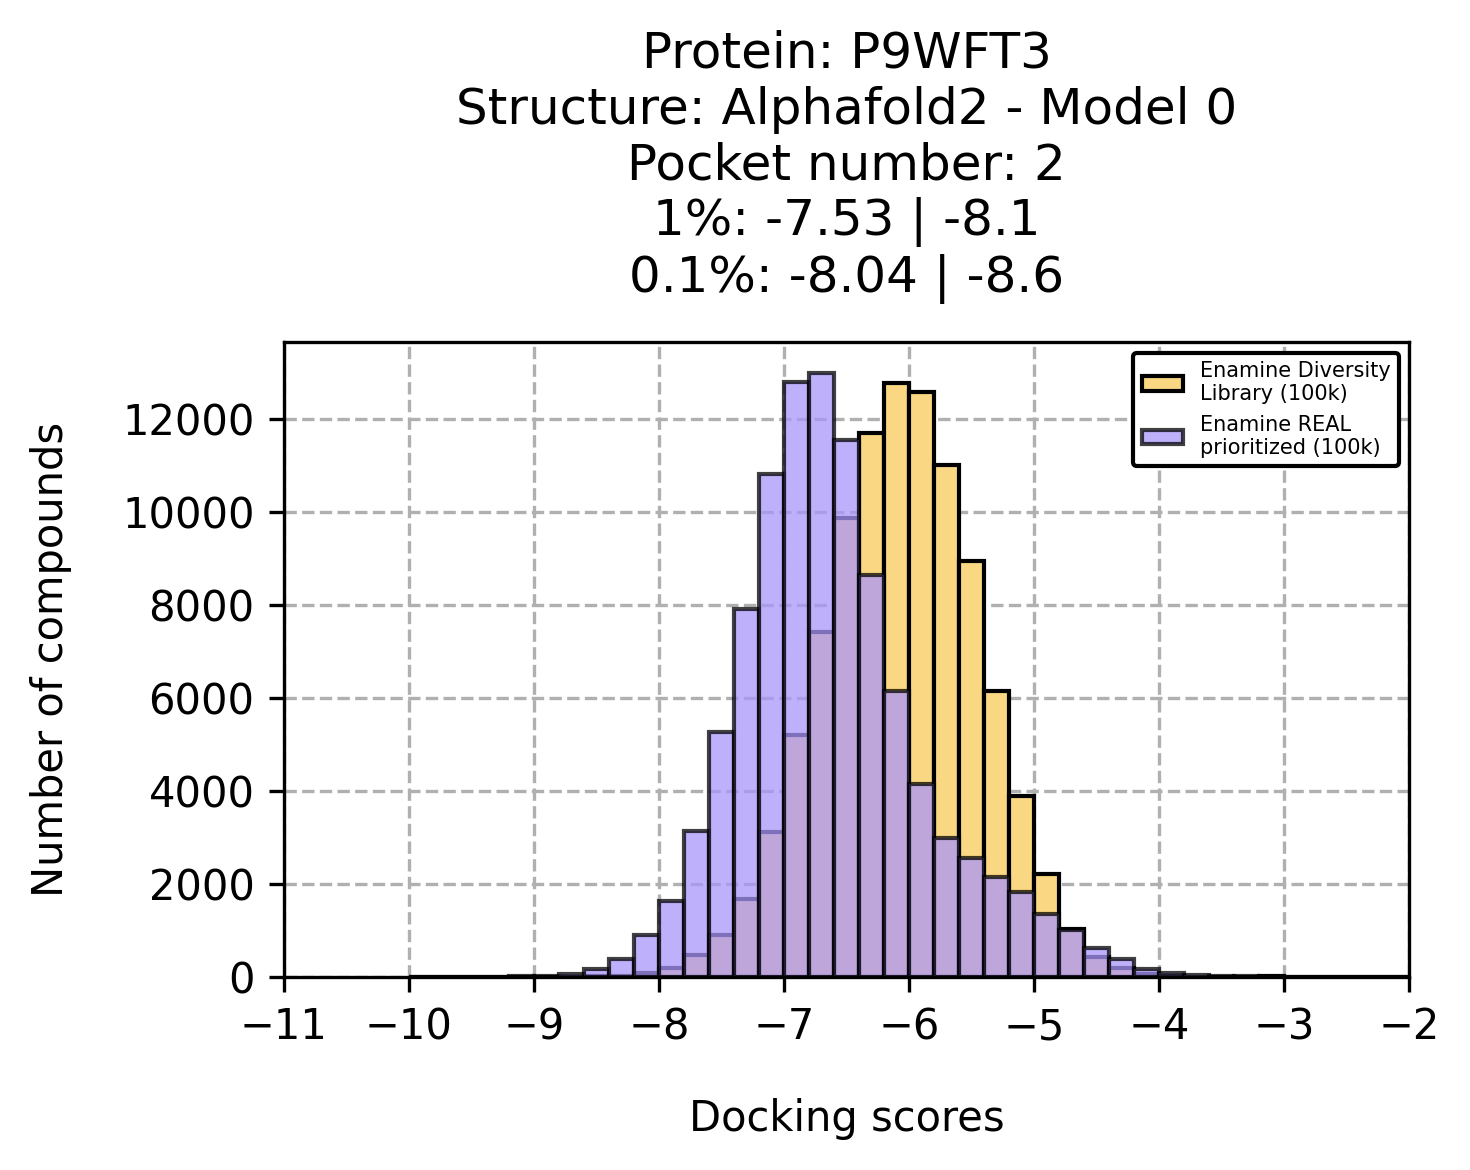

In [8]:
pocket = 'alphafold2_P9WFT3_model_0_pocket_2'
bins = [i for i in np.arange(-10, 1, 0.2)]

y1 = list(DOCKING_RESULTS_ORIGINAL[pocket].values())
y2 = list(DOCKING_RESULTS_REAL[pocket].values())
p = f"Protein: {pocket.split('_')[1]}\nStructure: {pocket.split('_')[0].capitalize()} - Model {pocket.split('_')[3]}\nPocket number: {pocket.split('_')[-1]}"
title = f"{p}\n1%: {round(np.percentile(y1, 1), 2)} | {round(np.percentile(y2, 1), 2)}\n0.1%: {round(np.percentile(y1, 0.1), 2)} | {round(np.percentile(y2, 0.1), 2)}"



plt.figure(figsize=(5, 4))
plt.hist(y1, bins=bins, zorder=2, edgecolor='k', color="#FAD782", label='Enamine Diversity\nLibrary (100k)')
plt.hist(y2, bins=bins, zorder=2, edgecolor='k', color="#AA96FA", label='Enamine REAL\nprioritized (100k)', alpha=0.75)
plt.grid(linestyle='--', zorder=-2)
plt.xlim([-11, -2])
plt.xlabel("Docking scores", labelpad=12)
plt.ylabel("Number of compounds", labelpad=12)
plt.legend(loc='best', framealpha=1, edgecolor='k', prop={'size': 5})
plt.title(title, pad=12)
plt.tight_layout()
plt.show()

In [9]:
### BOXPLOTS ###

In [10]:
def simple_boxplot(ax, x, y, c, width):
    ax.boxplot(y, positions=[x], widths=width, patch_artist=True, whis=[1, 99], showfliers=False,
               boxprops=dict(facecolor=c, color='black', lw=0.25),
               medianprops=dict(color='black', lw=0.25),
               whiskerprops=dict(color='black', lw=0.25),
               capprops=dict(color='none', lw=0.25))

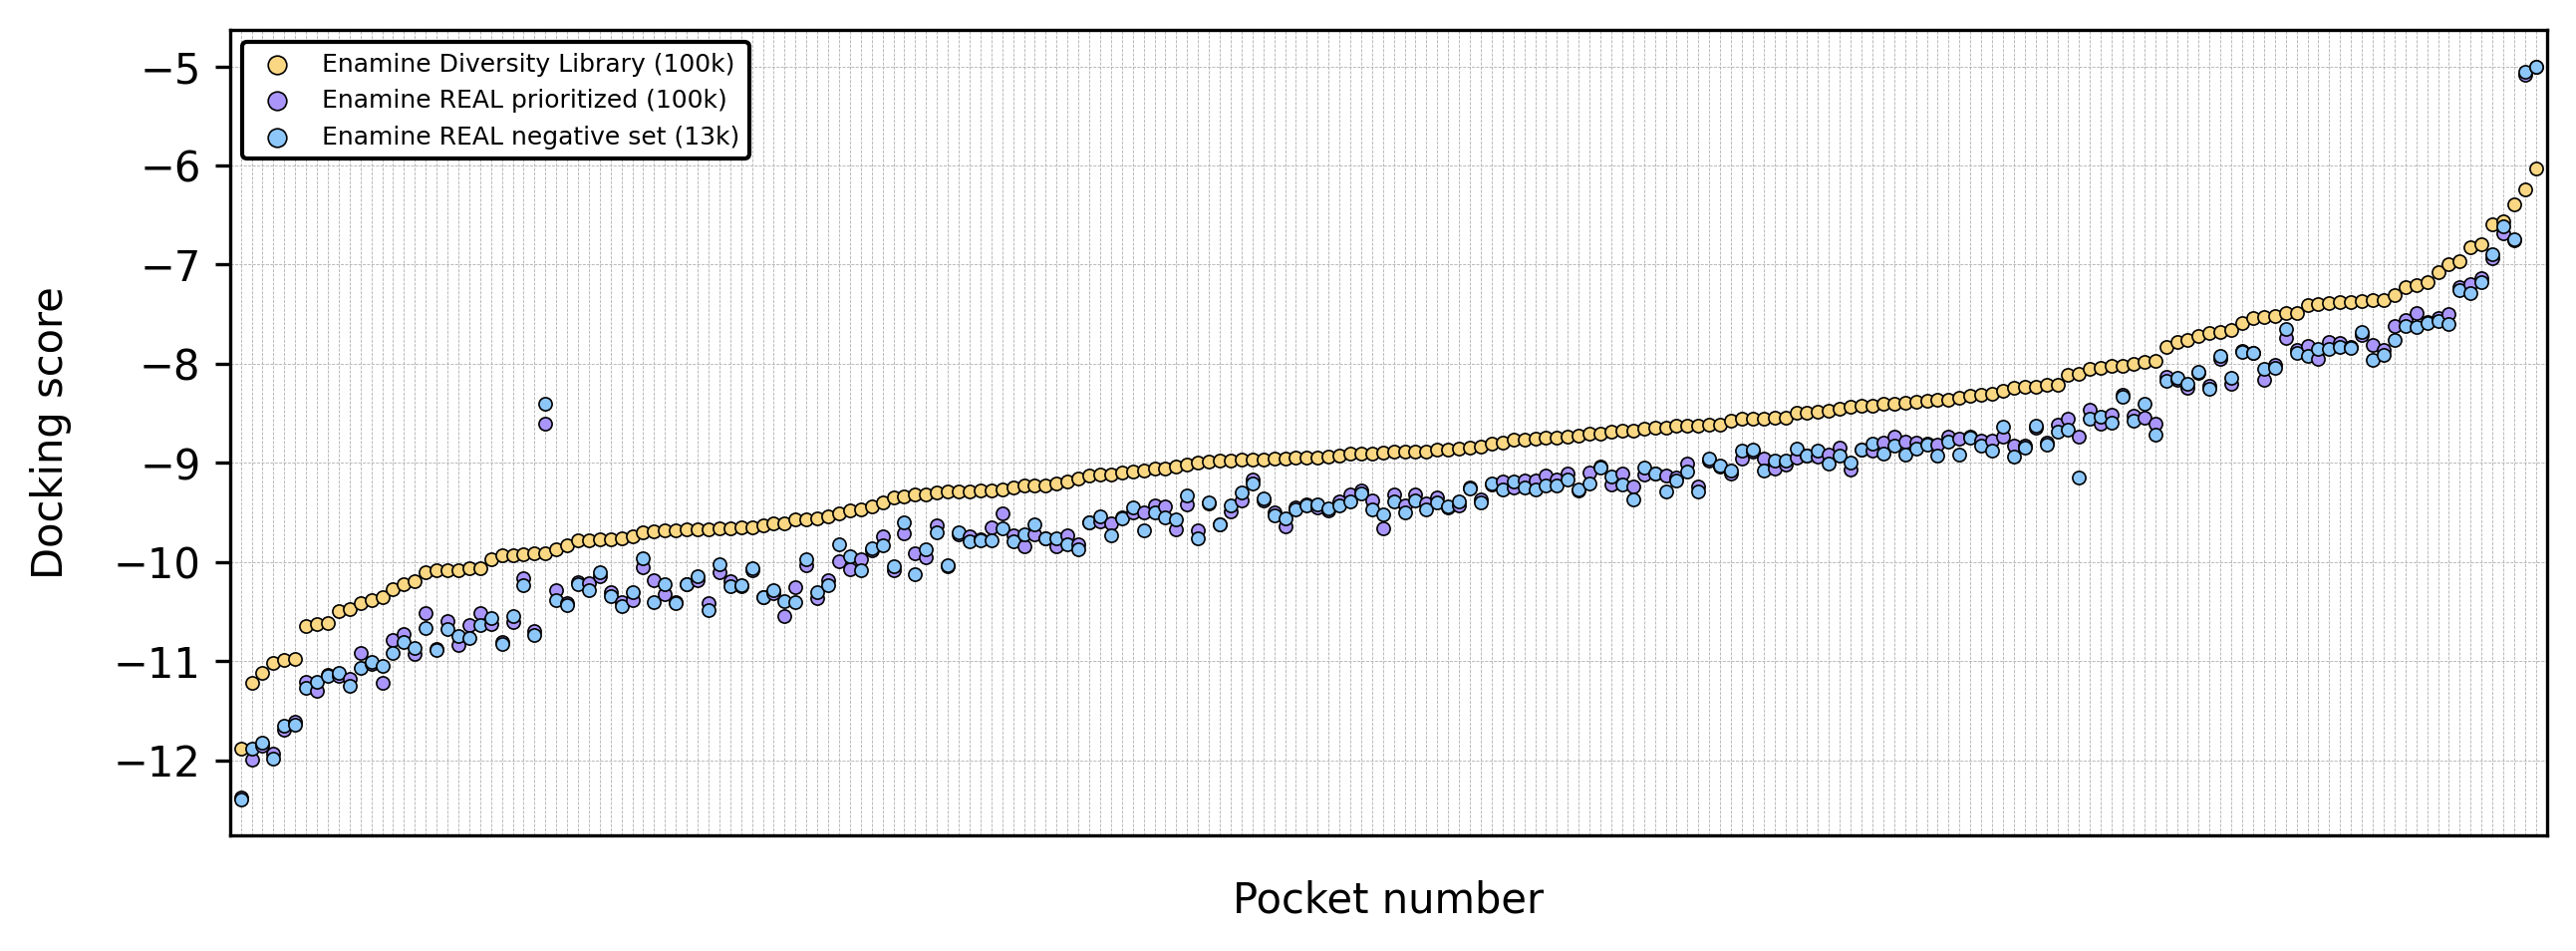

In [33]:
perc_min, perc_max = 0.1, 99
size, lw = 10, 0.4
diff = 0.2

# Sort pockets by median
# Sort pockets by percentile
# pockets = sorted(DOCKING_RESULTS_ORIGINAL)
pockets = [i for i in sorted(DOCKING_RESULTS_ORIGINAL) if i in DOCKING_RESULTS_REAL]
medians = [np.median(list(DOCKING_RESULTS_ORIGINAL[p].values())) for p in pockets]
percentiles = [np.percentile(list(DOCKING_RESULTS_ORIGINAL[p].values()), perc_min) for p in pockets]
ind = np.argsort(medians)
ind = np.argsort(percentiles)
pockets = np.array(pockets)[ind]

fig, ax = plt.subplots(figsize=(10, 3.5))
for c, pocket in enumerate(pockets):
    
    # Original
    l = list(DOCKING_RESULTS_ORIGINAL[pocket].values())
    # plt.scatter(c, np.median(l), c='#FAD782', ec='k', lw=lw, zorder=3, s=size)
    # pmin, pmax = np.percentile(l, perc_min), np.percentile(l, perc_max)
    # plt.plot([c, c], [pmin, pmax], c='k', zorder=2, lw=lw)
    plt.scatter(c, np.percentile(l, perc_min), c='#FAD782', ec='k', lw=lw, zorder=3, s=size)

    # REAL
    l = list(DOCKING_RESULTS_REAL[pocket].values())
    # plt.scatter(c-diff, np.median(l), c='#AA96FA', ec='k', lw=lw, zorder=3, s=size)
    # pmin, pmax = np.percentile(l, perc_min), np.percentile(l, perc_max)
    # plt.plot([c-diff, c-diff], [pmin, pmax], c='k', zorder=2, lw=lw)
    plt.scatter(c, np.percentile(l, perc_min), c='#AA96FA', ec='k', lw=lw, zorder=3, s=size)

    # REAL BACKGROUND
    l = list(DOCKING_RESULTS_REAL_BACKGROUND[pocket].values())
    # plt.scatter(c+diff, np.median(l), c='#8DC7FA', ec='k', lw=lw, zorder=3, s=size)
    # pmin, pmax = np.percentile(l, perc_min), np.percentile(l, perc_max)
    # plt.plot([c+diff, c+diff], [pmin, pmax], c='k', zorder=2, lw=lw)
    plt.scatter(c, np.percentile(l, perc_min), c='#8DC7FA', ec='k', lw=lw, zorder=3, s=size)

plt.xticks([i for i in range(len(pockets))], ["" for i in range(len(pockets))])
plt.tick_params(axis='x', length=0)
# plt.ylim([-11, 6])
plt.xlim([-1, len(pockets)])
plt.grid(linestyle='--', zorder=-2, lw=0.2)
plt.xlabel("Pocket number", labelpad=7)
plt.ylabel("Docking score", labelpad=10)

legend_scatter = []
legend_scatter.append(ax.scatter([], [], s=20, color="#FAD782", edgecolor='black', linewidth=lw, label="Enamine Diversity Library (100k)"))
legend_scatter.append(ax.scatter([], [], s=20, color="#AA96FA", edgecolor='black', linewidth=lw, label="Enamine REAL prioritized (100k)"))
legend_scatter.append(ax.scatter([], [], s=20, color="#8DC7FA", edgecolor='black', linewidth=lw, label="Enamine REAL negative set (13k)"))
ax.legend(handles=legend_scatter, loc="upper left", fontsize=6, edgecolor='k', framealpha=1)
plt.show()